# Лабораторная работа №1 (исправленная версия)

## Анализ датасета `blink.csv`


Данный ноутбук является продолжением первичного исследования датасета blink.

Цель работы — углубленный анализ структуры данных, типов признаков,
природы пропусков, выбросов и статистических характеристик.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

sns.set_theme(style="whitegrid")

df_raw = pd.read_csv('blink.csv', skiprows=1)

SENTINEL_THRESHOLD = 9e18
MOD = 2**40

df.head()

,id,anchorID,tagID,sequenceID,pan,processed_flag,timestampToA,Timestamp ToA
0,1,ANCH0001,TAG00001,0,0,1,7.284800e+11,728480463493
1,2,ANCH0004,TAG00001,0,0,1,7.284800e+11,728480463235
2,3,ANCH0002,TAG00001,0,0,1,7.284800e+11,728480462804
3,4,ANCH0003,TAG00001,0,0,1,7.284800e+11,728480463013
4,5,ANCH0001,TAG00001,1,0,1,7.590540e+11,759053775951


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              608 non-null    int64  
 1   anchorID        608 non-null    object 
 2   tagID           608 non-null    object 
 3   sequenceID      608 non-null    int64  
 4   pan             608 non-null    int64  
 5   processed_flag  608 non-null    int64  
 6   timestampToA    608 non-null    float64
 7   Timestamp ToA   608 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 38.1+ KB


## Первичное понимание данных

В датасете 608 строк и 8 исходных признаков:

- `id` — числовой идентификатор строки;
- `anchorID` — идентификатор якоря;
- `tagID` — идентификатор тега;
- `sequenceID` — номер последовательности;
- `pan` — код/идентификатор сети (в этом фрагменте всегда 0);
- `processed_flag` — бинарный признак обработки;
- `timestampToA` — округлённая версия времени прихода сигнала;
- `Timestamp ToA` — более точная версия времени прихода сигнала.

Важно: `timestampToA` и `Timestamp ToA` дублируют одно и то же значение, но с разной точностью.

Для анализа будем использовать **`Timestamp ToA`**, потому что он хранит больше информации.

In [7]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nunique": df.nunique(),
    "missing": df.isna().sum()
})
display(summary)

,dtype,nunique,missing
id,int64,608,0
anchorID,object,4,0
tagID,object,1,0
sequenceID,int64,164,0
pan,int64,1,0
processed_flag,int64,2,0
timestampToA,float64,189,0
Timestamp ToA,int64,602,0


# Задание 1. Типы признаков и шкалы измерения

| Признак | Тип шкалы | Почему |
|---|---|---|
| `id` | **номинальная** (идентификатор) | число есть, но арифметика над ним не интерпретируется |
| `anchorID` | **номинальная** | это код устройства, а не измерение |
| `tagID` | **номинальная** | это код объекта; в данном файле ещё и константный |
| `sequenceID` | **порядковая** | задаёт порядок наблюдений, но отношение "в 2 раза больше" смысла не имеет |
| `pan` | **номинальная** | это код/категория, хотя записан числом |
| `processed_flag` | **номинальная** (дихотомическая) | два состояния: 0/1 |
| `timestampToA` | **интервальная** | это временная метка/значение счётчика; разности осмысленны, отношения — нет |
| `Timestamp ToA` | **интервальная** | то же самое, но с большей точностью |

### Два признака с разными шкалами

Возьмем:

1. `anchorID` — номинальная шкала  
2. `Timestamp ToA` — интервальная шкала

### Какие агрегаты имеют смысл?

#### 1) `anchorID`
- среднее — математически и методологически неверно;
- медиана — неверно;
- мода — корректно.

Даже если закодировать `ANCH0001`, `ANCH0002`, ... числами, среднее не будет иметь содержательной интерпретации.  

#### 2) `Timestamp ToA`
- среднее — математически корректно, но методологически опасно, если есть sentinel-значения и переполнение счётчика;
- медиана — корректна и устойчивее к ошибкам/аномалиям;
- мода — возможна, но почти бесполезна для почти непрерывной величины.

### Вывод по заданию 1

`pandas` может посчитать среднее почти для любого числового столбца, но это не означает, что агрегат содержательно корректен.

# Задание 2. Диагностика типа пропусков

В `Timestamp ToA` есть 5 подозрительных значений:

- `9223372036854770000`

Это почти совпадает с `2^63 - 1` и очень похоже на специальный код ошибки.  
Будем рассматривать их как пропуски.

Но маленькие значения типа `60107040940` не будем считать за пропуски, потому что они согласуются с переполнением счётчика времени по модулю `2^40`.

Выполним преобразование:
1. значения вида `9223372036854770000` трактуются как sentinel-коды ошибки, то есть как пропуски;
2. для `Timestamp ToA` и `timestampToA` создаются очищенные версии с `NaN`;
3. добавляются индикаторы пропуска;
4. для `Timestamp ToA` строится "развёрнутая" версия с учётом переполнения счётчика по модулю `2^40`;
5. результат сохраняется в новый файл `blink_cleaned.csv`.


In [8]:
# создаём производную версию датасета из исходного blink.csv
df_lab = df_raw.copy()

# 1) sentinel-коды ошибки -> индикаторы псевдопропуска + очищенные версии
for col in ['Timestamp ToA', 'timestampToA']:
    miss_col = f'{col}_missing_ind'
    clean_col = f'{col}_clean'
    df_lab[miss_col] = (df_lab[col] >= SENTINEL_THRESHOLD).astype(int)
    df_lab[clean_col] = df_lab[col].where(df_lab[col] < SENTINEL_THRESHOLD, np.nan)

# 2) разворачивание переполнения счётчика для Timestamp ToA
seq_median = df_lab.groupby('sequenceID')['Timestamp ToA_clean'].median()
wrap_points = (seq_median.diff() < -5e11).fillna(False)
wrap_count = wrap_points.cumsum()

df_lab['wrap_count'] = df_lab['sequenceID'].map(wrap_count)
df_lab['Timestamp ToA_unwrapped'] = df_lab['Timestamp ToA_clean'] + df_lab['wrap_count'] * MOD

# при желании можно сделать и для timestampToA
seq_median_small = df_lab.groupby('sequenceID')['timestampToA_clean'].median()
wrap_points_small = (seq_median_small.diff() < -5e11).fillna(False)
wrap_count_small = wrap_points_small.cumsum()

df_lab['timestamp_wrap_count'] = df_lab['sequenceID'].map(wrap_count_small)
df_lab['timestampToA_unwrapped'] = df_lab['timestampToA_clean'] + df_lab['timestamp_wrap_count'] * MOD

# 3) сохраняем новый файл, не изменяя исходный
clean_path = 'blink_cleaned.csv'
df_lab.to_csv(clean_path, index=False)

print('Создан новый файл:', clean_path)
print('Размер производного датасета:', df_lab.shape)
print('Псевдопропусков в Timestamp ToA:', int(df_lab['Timestamp ToA_missing_ind'].sum()))
print('Псевдопропусков в timestampToA:', int(df_lab['timestampToA_missing_ind'].sum()))
print('Точки переполнения для Timestamp ToA:', list(wrap_points[wrap_points].index))

# дальше в ноутбуке работаем именно с производной версией
df = df_lab.copy()

display(df.head())

Создан новый файл: blink_cleaned.csv
Размер производного датасета: (608, 16)
Псевдопропусков в Timestamp ToA: 5
Псевдопропусков в timestampToA: 5
Точки переполнения для Timestamp ToA: [16, 53, 84, 102, 141]


,id,anchorID,tagID,sequenceID,pan,processed_flag,timestampToA,Timestamp ToA,Timestamp ToA_missing_ind,Timestamp ToA_clean,timestampToA_missing_ind,timestampToA_clean,wrap_count,Timestamp ToA_unwrapped,timestamp_wrap_count,timestampToA_unwrapped
0,1,ANCH0001,TAG00001,0,0,1,7.284800e+11,728480463493,0,7.284805e+11,0,7.284800e+11,0,7.284805e+11,0,7.284800e+11
1,2,ANCH0004,TAG00001,0,0,1,7.284800e+11,728480463235,0,7.284805e+11,0,7.284800e+11,0,7.284805e+11,0,7.284800e+11
2,3,ANCH0002,TAG00001,0,0,1,7.284800e+11,728480462804,0,7.284805e+11,0,7.284800e+11,0,7.284805e+11,0,7.284800e+11
3,4,ANCH0003,TAG00001,0,0,1,7.284800e+11,728480463013,0,7.284805e+11,0,7.284800e+11,0,7.284805e+11,0,7.284800e+11
4,5,ANCH0001,TAG00001,1,0,1,7.590540e+11,759053775951,0,7.590538e+11,0,7.590540e+11,0,7.590538e+11,0,7.590540e+11


In [9]:
# Проверим, что производная версия действительно создана корректно
print('Текущий рабочий датафрейм содержит столбцы:')
display(pd.Series([
    'Timestamp ToA_missing_ind',
    'Timestamp ToA_clean',
    'Timestamp ToA_unwrapped',
    'timestampToA_missing_ind',
    'timestampToA_clean',
    'timestampToA_unwrapped'
]))

print('Количество псевдопропусков в Timestamp ToA:', int(df['Timestamp ToA_missing_ind'].sum()))
print('Количество псевдопропусков в timestampToA:', int(df['timestampToA_missing_ind'].sum()))

Текущий рабочий датафрейм содержит столбцы:


,0
0,Timestamp ToA_missing_ind
1,Timestamp ToA_clean
2,Timestamp ToA_unwrapped
3,timestampToA_missing_ind
4,timestampToA_clean
5,timestampToA_unwrapped


Количество псевдопропусков в Timestamp ToA: 5
Количество псевдопропусков в timestampToA: 5


In [10]:
suspicious = df.loc[
    (df['Timestamp ToA_missing_ind'] == 1) | (df['Timestamp ToA'] < 1e11),
    ['id', 'anchorID', 'sequenceID', 'Timestamp ToA', 'Timestamp ToA_clean', 'Timestamp ToA_unwrapped']
].sort_values(['sequenceID', 'anchorID'])

display(suspicious.head(20))

,id,anchorID,sequenceID,Timestamp ToA,Timestamp ToA_clean,Timestamp ToA_unwrapped
55,56,ANCH0002,15,9223372036854770000,NaN,NaN
54,55,ANCH0003,15,9223372036854770000,NaN,NaN
53,54,ANCH0004,15,9223372036854770000,NaN,NaN
56,57,ANCH0001,16,60107040940,6.010704e+10,1.159619e+12
59,60,ANCH0002,16,60107040230,6.010704e+10,1.159619e+12
57,58,ANCH0003,16,60107040387,6.010704e+10,1.159619e+12
58,59,ANCH0004,16,60107040666,6.010704e+10,1.159619e+12
200,201,ANCH0002,53,9223372036854770000,NaN,NaN
201,202,ANCH0003,53,12466668084,1.246667e+10,2.211490e+12
202,203,ANCH0004,53,9223372036854770000,NaN,NaN


## 2.1. Три альтернативные гипотезы

### Гипотеза 1: MCAR
Пропуски возникают полностью случайно и не зависят ни от `anchorID`, ни от `sequenceID`, ни от `processed_flag`.

**Что может подтвердить / опровергнуть**
- одинаковые доли пропусков по `anchorID`;
- отсутствие кластеризации по `sequenceID`;
- отсутствие связи с `processed_flag`.

**Какие проверки выполнить**
- таблицы сопряжённости и `chi-square` для `anchorID` и `processed_flag`;
- график доли пропусков по `sequenceID`.

---

### Гипотеза 2: MAR
Пропуски зависят от наблюдаемых признаков, например от:
- `anchorID`;
- `sequenceID`;
- положения около точки переполнения счётчика.

**Что может подтвердить / опровергнуть**
- заметно разные доли пропусков по якорям;
- концентрация пропусков в отдельных последовательностях.

**Какие проверки выполнить**
- `groupby` по `anchorID` и `sequenceID`;
- сравнение пропусков около переполнения и вне него.

---

### Гипотеза 3: MNAR
Пропуски зависят от самого истинного значения времени, которое мы не наблюдаем.  
Например, когда истинный timestamp попадает в технически проблемную область: очень близко к переполнению или в момент аппаратной ошибки.

**Что может подтвердить / опровергнуть**
- пропуски возникают именно в тех местах, где соседние значения близки к верхней границе счётчика;
- нет сильной зависимости от `anchorID`, но есть зависимость от самой природы измерения.

**Какие проверки выполнить**
- анализ соседних последовательностей;
- проверка, возникают ли пропуски рядом с переходом через модуль `2^40`;
- содержательная интерпретация sentinel-значения.

In [11]:
# Проверка 1: связь псевдопропусков с anchorID
ct_anchor = pd.crosstab(df['anchorID'], df['Timestamp ToA_missing_ind'])
display(ct_anchor)

chi2_anchor = chi2_contingency(ct_anchor)
print("p-value для связи с anchorID:", chi2_anchor.pvalue)

# Проверка 2: связь псевдопропусков с processed_flag
ct_processed = pd.crosstab(df['processed_flag'], df['Timestamp ToA_missing_ind'])
display(ct_processed)

chi2_processed = chi2_contingency(ct_processed)
print("p-value для связи с processed_flag:", chi2_processed.pvalue)

Timestamp ToA_missing_ind,0,1
anchorID,,
ANCH0001,133,0
ANCH0002,162,2
ANCH0003,146,1
ANCH0004,162,2


p-value для связи с anchorID: 0.6207178996151757


Timestamp ToA_missing_ind,0,1
processed_flag,,
0,41,0
1,562,5


p-value для связи с processed_flag: 1.0


,Timestamp ToA_missing_ind
sequenceID,
15,0.750000
53,0.666667


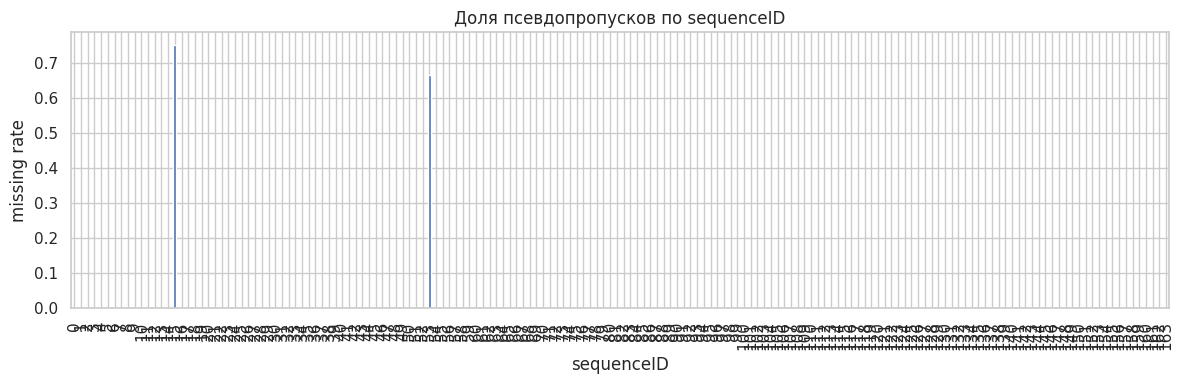

In [12]:
# Проверка 3: доля пропусков по sequenceID
missing_by_seq = df.groupby('sequenceID')['Timestamp ToA_missing_ind'].mean()
display(missing_by_seq[missing_by_seq > 0])

plt.figure(figsize=(12, 4))
missing_by_seq.plot(kind='bar')
plt.title('Доля псевдопропусков по sequenceID')
plt.xlabel('sequenceID')
plt.ylabel('missing rate')
plt.tight_layout()
plt.show()

## 2.2. Вывод по заданию 2

Получается следующая картина:

- пропусков в явном виде нет, но есть **5 псевдопропусков** в `Timestamp ToA`;
- по `anchorID` статистически убедимой связи не видно (`p ≈ 0.621`);
- по `processed_flag` связи тоже нет (`p = 1.000`);
- зато пропуски сконцентрированы только в `sequenceID = 15` и `sequenceID = 53`.

Это делает гипотезу MCAR слабой: если бы пропуски были полностью случайны, они не собирались бы в двух конкретных последовательностях.

Гипотеза **MAR** выглядит правдоподобной, если считать `sequenceID` наблюдаемым фактором: пропуски явно зависят от положения в последовательности.

Гипотеза **MNAR** тоже очень правдоподобна и даже содержательно сильнее: sentinel возникает, когда реальное значение времени попадает в проблемную зону измерения (переполнение/сбой счётчика).

# Задание 3. Индикатор пропуска как источник информации

### 1. Когда сам факт пропуска несёт информацию?
Факт пропуска информативен тогда, когда отсутствие значения связано не со случайностью, а с состоянием объекта, процесса измерения или источника данных.

Для этого датасета хороший пример — `Timestamp ToA`.  
Если вместо значения появляется sentinel, это может говорить:

- произошёл сбой измерения;
- счётчик был около переполнения;
- конкретный сигнал не был корректно обработан.

То есть индикатор пропуска может нести информацию о режиме работы системы.

### 2. Почему значимость индикатора в модели может быть сигналом грубой импутации?
Если мы просто подставим вместо пропусков одно число (например, медиану), то модель начнёт отличать:
- реальные наблюдения;
- искусственно заполненные.

Тогда модель использует не восстановленное значение, а сам факт того, что значение было "дорисовано".  
Это часто означает, что импутация слишком грубая и не сохраняет структуру данных.

### 3. Примеры

**Полезен**  
- `Timestamp ToA`: sentinel может отражать сбой устройства или overflow.

**Бесполезен**  
- `tagID`: в этом датасете значение одно и то же (`TAG00001`), поэтому даже если бы там не хватало пары значений, такой индикатор почти ничего бы не дал.

**Опасен**  
- `anchorID` или другой технический признак после неудачного merge/import.  
  Тогда индикатор может кодировать не реальное поведение объекта, а артефакт подготовки данных.  
  Модель будет "учиться на ошибке пайплайна", а не на закономерности предметной области.

# Задание 4. Выброс — это ошибка или сигнал?

Выберем признак `Timestamp ToA` и выброс `9223372036854770000`.

### 1. Какие реальные причины могут объяснить это значение?
Наиболее вероятные причины:

1. sentinel-значение для ошибки или отсутствия измерения;
2. переполнение `int64` / использование максимума типа как служебной метки;
3. ошибка выгрузки или парсинга;
4. аппаратный сбой в момент измерения.

### 2. Что хуже для анализа?

#### Оставить без изменений
Это **самый плохой вариант**.  
Такое значение:
- полностью ломает среднее и стандартное отклонение;
- искажает гистограммы, boxplot и масштаб осей;
- делает распределение искусственно "сверхправосторонним".

#### Удалить строку целиком
Лучше, чем оставить выброс, но не идеально.  
Мы можем потерять полезную информацию из других столбцов (`anchorID`, `sequenceID`, `processed_flag`).

#### Применить преобразование
Для такого случая это тоже плохое решение.  
Логарифмирование или корень не исправляют смысловую ошибку, а просто маскируют её.

### Вывод
Для этого выброса лучший шаг — не удалять всё наблюдение и не трансформировать значение,   а перекодировать его в пропуск именно в столбце времени и дальше работать как с missing value.

# Задание 5. Преобразование или винзоризация?

Для этого датасета сильная асимметрия в `Timestamp ToA` появляется главным образом из-за sentinel-значений.  
Это важный методологический вывод:

> Перед логарифмированием, корнем или винзоризацией надо сначала понять,  
> не вызвана ли асимметрия просто ошибочными значениями.

## Когда что предпочитать?

### 1. Логарифмирование
Подходит, когда:
- признак положительный;
- разброс большой;
- важны относительные, а не абсолютные различия;
- эффект скорее мультипликативный.

**Плюсы**
- хорошо сжимает длинный правый хвост;
- помогает линейным моделям;
- делает распределение ближе к симметричному.

**Минусы**
- теряется исходная шкала;
- нельзя применять к нулям и отрицательным значениям без дополнительной обработки.

### 2. Квадратный корень
Подходит, когда:
- асимметрия умеренная;
- не хочется слишком сильно сжимать большие значения.

**Плюсы**
- мягче логарифма;
- проще интерпретировать.

**Минусы**
- слабее борется с очень длинным хвостом.

### 3. Винзоризация
Подходит, когда:
- крайние значения похожи на шум измерения;
- мы хотим сохранить размер выборки;
- выбросы немногочисленны и не являются отдельным содержательным режимом.

**Плюсы**
- стабилизирует среднее и дисперсию;
- сохраняет число наблюдений.

**Минусы**
- искажает реальные экстремальные значения;
- может скрыть важный сигнал;
- при техническом sentinel-значении это хуже, чем явная перекодировка в пропуск.

## Как методы влияют на анализ?

### Интерпретируемость
- логарифм: интерпретация сложнее, потому что шкала уже не исходная;
- корень: интерпретация чуть проще;
- винзоризация: шкала остаётся похожей на исходную, но хвост искусственно обрезается.

### Линейные модели
- логарифм часто полезнее всего;
- корень — компромиссный вариант;
- винзоризация помогает, если проблема именно в редких выбросах.

### Визуализация распределений
- логарифм и корень делают гистограммы компактнее;
- винзоризация убирает слишком длинные хвосты, но может скрыть реальные экстремумы.

### Вывод именно для blink
Для `Timestamp ToA` сначала нужно:
1. заменить sentinel на `NaN`,
2. при необходимости развернуть переполнение счётчика,
3. и только потом решать, нужно ли вообще преобразование.

То есть для этого датасета очистка важнее, чем логарифмирование или винзоризация.

In [13]:
# Сравним влияние очистки на статистики времени
raw = df['Timestamp ToA'].astype(float)
clean_time = df['Timestamp ToA_clean'].dropna()

raw_mean = raw.mean()
raw_median = raw.median()
raw_gmean = np.exp(np.log(raw).mean())

clean_mean = clean_time.mean()
clean_median = clean_time.median()
clean_gmean = np.exp(np.log(clean_time).mean())

stats_compare = pd.DataFrame({
    "raw_with_sentinel": [raw_mean, raw_median, raw_gmean],
    "clean_without_sentinel": [clean_mean, clean_median, clean_gmean]
}, index=["arithmetic_mean", "median", "geometric_mean"])

display(stats_compare)

,raw_with_sentinel,clean_without_sentinel
arithmetic_mean,7.585067e+16,5.729546e+11
median,5.847331e+11,5.847331e+11
geometric_mean,5.275731e+11,4.594390e+11


# Задание 6. Средние, которые вводят в заблуждение

Возьмём признак **`Timestamp ToA`**.

### 1. Сравнение средних

Для исходного столбца (с sentinel):

- арифметическое среднее ≈ **7.585e+16**
- медиана = **5.847е+11**
- геометрическое среднее ≈ **5.276e+11**

После перекодировки sentinel в пропуск:

- арифметическое среднее ≈ **5.730e+11**
- медиана = **5.847е+11**
- геометрическое среднее ≈ **4.594e+11**

### 2. Почему они различаются?

Потому что арифметическое среднее очень чувствительно к нескольким гигантским значениям.  
Пяти sentinel-значений оказалось достаточно, чтобы поднять среднее до порядка `10^16`, хотя типичные наблюдения находятся в районе `10^11`–`10^12`.

Геометрическое среднее менее чувствительно к таким выбросам, поэтому оно ближе к реальному масштабу.  
Медиана вообще почти не реагирует на несколько испорченных наблюдений.

### 3. Какое лучше отражает "типичное" значение?

Для исходного грязного столбца лучший выбор — **медиана**.  
Причины:

- она устойчива к выбросам;
- не ломается от sentinel-значений;
- лучше соответствует визуально "центру" распределения.

После очистки столбца арифметическое среднее уже становится осмысленнее, но даже тогда медиана остаётся хорошей характеристикой "типичного" времени.

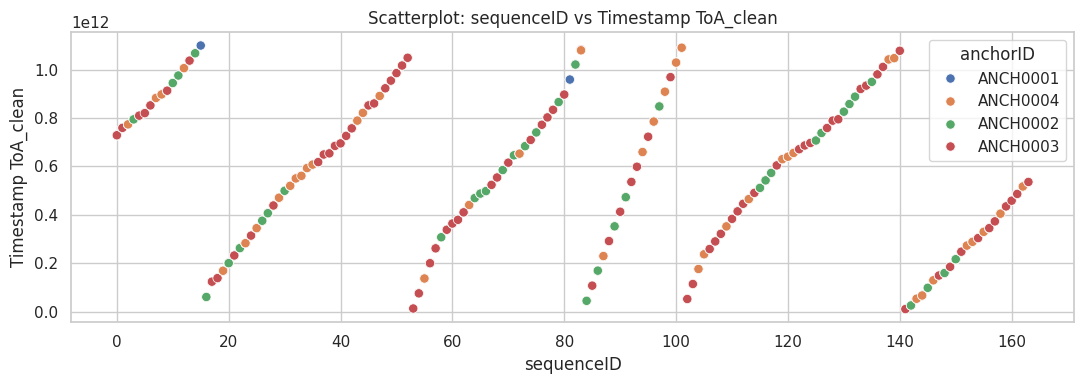

In [14]:
plt.figure(figsize=(11, 4))
sns.scatterplot(data=df, x='sequenceID', y='Timestamp ToA_clean', hue='anchorID', s=45)
plt.title('Scatterplot: sequenceID vs Timestamp ToA_clean')
plt.tight_layout()
plt.show()

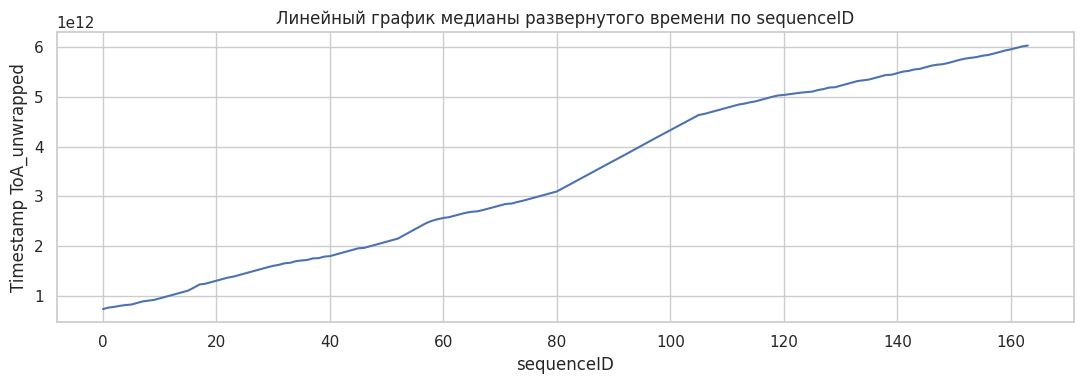

In [15]:
median_line = df.groupby('sequenceID', as_index=False)['Timestamp ToA_unwrapped'].median()

plt.figure(figsize=(11, 4))
sns.lineplot(data=median_line, x='sequenceID', y='Timestamp ToA_unwrapped')
plt.title('Линейный график медианы развернутого времени по sequenceID')
plt.tight_layout()
plt.show()

# Задание 7. Неправильная диаграмма

Возьмем визуализацию зависимости `sequenceID` и `Timestamp ToA`  

## Какая диаграмма была бы хуже?
Линейный график по всем сырым точкам был бы хуже, если просто соединить наблюдения в порядке строк.

## Что именно он исказил бы?
Он создал бы ложное впечатление, что:
- точки образуют одну непрерывную траекторию;
- между соседними строками есть физически осмысленная связь;
- резкие скачки — это настоящая динамика процесса.

Но в реальности:
- строки относятся к разным `anchorID`;
- часть значений — sentinel;
- есть переполнение счётчика, которое даёт искусственные "обрывы".

## Какой неверный вывод мог бы сделать зритель?
Зритель мог бы решить, что:
- система периодически "падает" или "взрывается" по времени сигнала;
- между соседними наблюдениями есть сильные рывки;
- видна непрерывная временная траектория одного объекта.

На самом деле такой вывод был бы следствием неудачного типа диаграммы, а не структуры данных.

# Задание 8. Одна и та же информация — разные графики

Возьмём пару признаков:

- `sequenceID`
- `Timestamp ToA` (лучше в очищенном/развёрнутом виде)

## Вариант 1. Scatterplot
Что подчёркивает:
- разброс значений внутри каждого `sequenceID`;
- различия между `anchorID`;
- отдельные аномальные точки и пропуски.

Какие гипотезы легче заметить:
- есть ли кластеры;
- есть ли выбросы;
- есть ли разные режимы работы по якорям.

## Вариант 2. Line plot по медиане `Timestamp ToA_unwrapped` для каждого `sequenceID`
Что подчёркивает:
- общий тренд по последовательности;
- точки переполнения и восстановленную монотонность после "разворачивания";
- плавность или неплавность глобального процесса.

Какие гипотезы легче заметить:
- есть ли общий рост/тренд;
- где происходят переходы между циклами счётчика;
- насколько монотонен процесс в целом.

## Почему один график не заменяет другой?
- **Scatterplot** лучше показывает локальный разброс и аномальные точки.
- **Line plot по медиане** лучше показывает глобальную структуру.

То есть это одна и та же информация, но:
- первый график хорош для диагностики шума и выбросов;
- второй — для понимания общей временной логики.